## **Dataset**

**Description**
[Kaggle](https://www.kaggle.com/competitions/otto-group-product-classification-challenge/overview)

The Otto Group is one of the world’s biggest e-commerce companies, with subsidiaries in more than 20 countries, including Crate & Barrel (USA), Otto.de (Germany) and 3 Suisses (France). We are selling millions of products worldwide every day, with several thousand products being added to our product line.

A consistent analysis of the performance of our products is crucial. However, due to our diverse global infrastructure, many identical products get classified differently. Therefore, the quality of our product analysis depends heavily on the ability to accurately cluster similar products. The better the classification, the more insights we can generate about our product range.


For this, we have provided a dataset with 93 features for more than 200,000 products. The objective is to build a predictive model which is able to distinguish between our main product categories. The winning models will be open sourced.


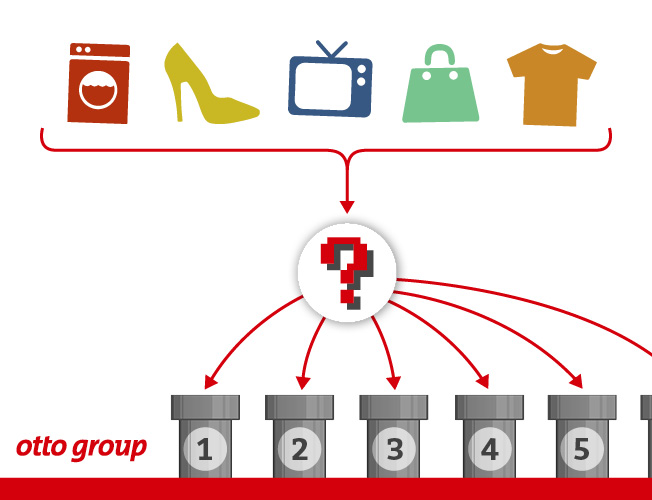

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# 1. LOAD AND PREPROCESS DATA
# Assume 'train.csv' is in the same directory
df = pd.read_csv('train.csv')
df.head()

,id,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_85,feat_86,feat_87,feat_88,feat_89,feat_90,feat_91,feat_92,feat_93,target
0,1,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,Class_1
1,2,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,Class_1
2,3,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,Class_1
3,4,1,0,0,1,6,1,5,0,0,...,0,1,2,0,0,0,0,0,0,Class_1
4,5,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,Class_1


#### **Data fields**
- id - an anonymous id unique to a product
- feat_1, feat_2, ..., feat_93 - the various features of a product
- target - the class of a product

## **Data Preprocessing & Splitting & Scaling**

Below we used `LabelEncoder()` to to convert categorical labels (text or other non-numeric data) into numerical values ranging from to classes.

**Question:** What is the difference between `get_dummies()` and `LabelEncoder()` conceptually, and when do we use each?

In [ ]:
# The Otto dataset has an 'id' column we don't need
X = df.drop(['id', 'target'], axis=1).values
y = df['target'].values

# Encode labels (Class_1, Class_2... -> 0, 1, 2...)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# First Split: Carve out 15% for the locked-away Test Set
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Second Split: Split the remaining 85% into Train and Validation
# Taking 18% of the remaining data gives us roughly 15% of the total dataset for Validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.18, random_state=42)

print(f"Train set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Train set size: 43128
Validation set size: 9468
Test set size: 9282


In [ ]:
# Scale the features properly
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # FIT and transform the training data
X_val = scaler.transform(X_val)         # ONLY transform validation
X_test = scaler.transform(X_test)       # ONLY transform testing

## **Tensors and DataLoaders**

In [ ]:
# Create DataLoaders
train_ds = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
val_ds = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
test_ds = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

## **Build the Model**

In [ ]:
class OttoNet(nn.Module):
    def __init__(self, ):
        super().__init__()

        self.layer1 = nn.Linear(93, 512)
        self.layer2 = nn.Linear(512, 256)
        self.layer3 = nn.Linear(256, 128)
        self.out = nn.Linear(128, 9) # 9 target classes

        self.relu = nn.ReLU()

    def forward(self, x):
        # Layer 1
        x = self.layer1(x)
        x = self.relu(x)

        # Layer 2
        x = self.layer2(x)
        x = self.relu(x)

        # Layer 3
        x = self.layer3(x)
        x = self.relu(x)

        return self.out(x)


model = OttoNet()
model

OttoNet(
  (layer1): Linear(in_features=93, out_features=512, bias=True)
  (layer2): Linear(in_features=512, out_features=256, bias=True)
  (layer3): Linear(in_features=256, out_features=128, bias=True)
  (out): Linear(in_features=128, out_features=9, bias=True)
  (relu): ReLU()
)

## **Loss Function & Optimizer**

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## **Training Loop**

In [ ]:
epochs = 100
train_losses, val_losses = [], []

for epoch in range(epochs):
    # --- TRAINING ---
    model.train()
    epoch_loss = 0

    for batch_X, batch_y in train_loader:

        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    # --- VALIDATION ---
    model.eval()
    epoch_val_loss = 0


    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            raw_predictions = model(batch_X)
            loss = criterion(raw_predictions, batch_y)
            epoch_val_loss += loss.item()


    val_losses.append(epoch_val_loss / len(val_loader))

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}] |Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}')



Epoch [10/100] |Train Loss: 0.3729 | Val Loss: 0.5352
Epoch [20/100] |Train Loss: 0.2338 | Val Loss: 0.7067
Epoch [30/100] |Train Loss: 0.1586 | Val Loss: 0.9002
Epoch [40/100] |Train Loss: 0.1018 | Val Loss: 1.2012
Epoch [50/100] |Train Loss: 0.0786 | Val Loss: 1.3894
Epoch [60/100] |Train Loss: 0.0687 | Val Loss: 1.5576
Epoch [70/100] |Train Loss: 0.0513 | Val Loss: 1.8149
Epoch [80/100] |Train Loss: 0.0544 | Val Loss: 1.9032
Epoch [90/100] |Train Loss: 0.0477 | Val Loss: 2.0140
Epoch [100/100] |Train Loss: 0.0392 | Val Loss: 2.0063


## **Save the Model Parameters**

In [ ]:
torch.save(model.state_dict(), 'OttoNetBase.pt')

## **Check for Overfitting**

- **The Training-Validation Gap:** Monitor the difference between your training metrics and validation metrics. A significant gap—where training accuracy is very high but validation accuracy is much lower—is a primary sign that the model has memorized the training set rather than learning general patterns.

- **Loss Curve Divergence:** Plot your loss over time (epochs). In a healthy model, both training and validation loss decrease together. If the training loss continues to drop while the validation loss starts to rise, your model is officially overfitting.

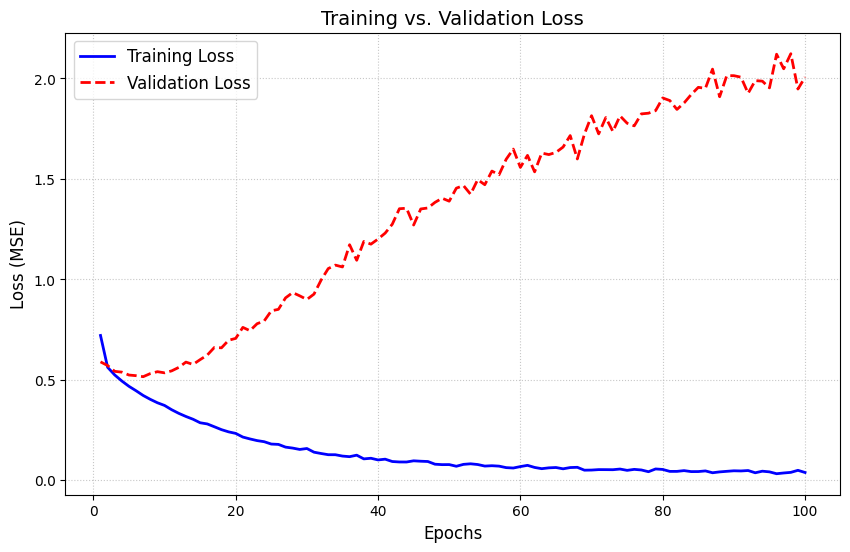

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', color='blue', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--')

plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training vs. Validation Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

##### **Clearly the model is overfitted!**

It can be also visible by comparing the test and train evaluation.

## **The Final Evaluation (Test Set)**



In [ ]:
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        # Get the raw logits from the model
        logits = model(batch_X)

        # Get the predicted class index by finding the maximum logit
        predictions = torch.argmax(logits, dim=1)

        # batch_y is already 1D (batch_size,) from test_loader
        test_correct += (predictions == batch_y).sum().item()
        test_total += batch_y.size(0)

final_accuracy = (test_correct / test_total) * 100

print("=" * 40)
print(f"FINAL TEST ACCURACY: {final_accuracy:.2f}%")
print("=" * 40)

# Display 5 specific customer examples
print("\nSample Customer Predictions:")

# Apply softmax to get actual probabilities for display
softmax_probs = torch.softmax(logits, dim=1)

for i in range(min(5, batch_X.size(0))): # Ensure we don't go out of bounds for small batches
    # Convert back to standard numbers for printing
    predicted_class_idx = predictions[i].item()
    actual_class_idx = batch_y[i].item()

    # Get the probability for the predicted class
    prob_of_predicted_class = softmax_probs[i, predicted_class_idx].item() * 100

    # Use label_encoder to get original class names for better readability
    # label_encoder is available from previous cells
    predicted_label = label_encoder.inverse_transform([predicted_class_idx])[0]
    actual_label = label_encoder.inverse_transform([actual_class_idx])[0]

    # Format the text to make it easy to read
    print(f"Customer {i+1}: Model predicted {predicted_label} (Certainty: {prob_of_predicted_class:.1f}%) | Actual: {actual_label}")


FINAL TEST ACCURACY: 78.95%

Sample Customer Predictions:
Customer 1: Model predicted Class_2 (Certainty: 95.2%) | Actual: Class_2
Customer 2: Model predicted Class_6 (Certainty: 100.0%) | Actual: Class_6
Customer 3: Model predicted Class_6 (Certainty: 100.0%) | Actual: Class_6
Customer 4: Model predicted Class_8 (Certainty: 100.0%) | Actual: Class_8
Customer 5: Model predicted Class_8 (Certainty: 100.0%) | Actual: Class_8


In [ ]:
model.eval()
train_correct = 0
train_total = 0

with torch.no_grad():
    for batch_X, batch_y in train_loader:
        # Get the raw logits from the model
        logits = model(batch_X)

        # Get the predicted class index by finding the maximum logit
        predictions = torch.argmax(logits, dim=1)

        # batch_y is already 1D (batch_size,) from test_loader
        train_correct += (predictions == batch_y).sum().item()
        train_total += batch_y.size(0)

final_accuracy = (train_correct / train_total) * 100

print("=" * 40)
print(f"FINAL TEST ACCURACY: {final_accuracy:.2f}%")
print("=" * 40)

# Display 5 specific customer examples
print("\nSample Customer Predictions:")

# Apply softmax to get actual probabilities for display
softmax_probs = torch.softmax(logits, dim=1)

for i in range(min(5, batch_X.size(0))): # Ensure we don't go out of bounds for small batches
    # Convert back to standard numbers for printing
    predicted_class_idx = predictions[i].item()
    actual_class_idx = batch_y[i].item()

    # Get the probability for the predicted class
    prob_of_predicted_class = softmax_probs[i, predicted_class_idx].item() * 100

    # Use label_encoder to get original class names for better readability
    # label_encoder is available from previous cells
    predicted_label = label_encoder.inverse_transform([predicted_class_idx])[0]
    actual_label = label_encoder.inverse_transform([actual_class_idx])[0]

    # Format the text to make it easy to read
    print(f"Customer {i+1}: Model predicted {predicted_label} (Certainty: {prob_of_predicted_class:.1f}%) | Actual: {actual_label}")


FINAL TEST ACCURACY: 98.78%

Sample Customer Predictions:
Customer 1: Model predicted Class_6 (Certainty: 100.0%) | Actual: Class_6
Customer 2: Model predicted Class_8 (Certainty: 100.0%) | Actual: Class_8
Customer 3: Model predicted Class_6 (Certainty: 100.0%) | Actual: Class_6
Customer 4: Model predicted Class_2 (Certainty: 96.5%) | Actual: Class_3
Customer 5: Model predicted Class_4 (Certainty: 100.0%) | Actual: Class_4


## **How to avoid overfitting?**


**Key Strategies to Prevent Overfitting**

- **Reduce Network Complexity:** Simplify the architecture by reducing the number of hidden layers and neurons per layer to limit the model's capacity to memorize input data.

- **Dropout:** Randomly deactivate a fraction of neurons during each training step, forcing the network to learn more robust features.


- **Weight Regularization (L1/L2):** Penalize large weights in the loss function to encourage smaller weights and a smoother model, which generalizes better.

- **Early Stopping:** Monitor validation loss during training and halt the process once the loss stops decreasing and begins to increase, preventing the model from learning noise.


- **Data Augmentation:** Increase training data diversity by applying random transformations (e.g., rotation, flipping, noise) to existing data, reducing reliance on specific samples.


- **Batch Normalization:** Normalizes the input layer, which can have a small, implicit regularization effect.


## **What is a Dropout?**


Dropout is a regularization technique in neural networks that randomly sets a fraction (rate) of input units to zero during training, preventing neurons from co-adapting and reducing overfitting.

**Co-adaptation** is a fancy way of saying neurons are "cheating" by relying on each other too much.
Instead of each neuron learning a useful feature on its own (like "this is a circle" or "this is a line"), neurons start to form complex relationships where one neuron fixes the mistakes of another.


**Why it’s a problem:**

- **Fragility:** The network becomes like a house of cards. If one "load-bearing" neuron gets it wrong, the whole chain of dependencies fails.
- **Overfitting:** The neurons aren't learning the actual patterns in the data; they’re just learning how to work together to perfectly memorize the specific examples they've already seen.


**How Dropout fixes it:**
For each batch during training, a different random set of nodes (neurons) is turned off (set to zero). This random deactivation forces the network to learn more robust features and prevents neurons from becoming overly reliant on each other, which helps in reducing overfitting. The dropout rate determines the fraction of neurons that are randomly dropped out in each batch.


By randomly turning neurons off, in each training step (forward pass), the network can't rely on any specific pair or group of neurons always being there. This forces every neuron to become a "generalist" that can provide value even when its usual partners are missing.

**Ensemble Approximation:** It is equivalent to training an ensemble of many different, smaller architectures (sub-networks in each iteration).


**Dropout visualized:** https://nnfs.io/def/


In [ ]:
class OttoNet_dropOut(nn.Module):
    def __init__(self, ):
        super().__init__()

        self.layer1 = nn.Linear(93, 512)
        self.layer2 = nn.Linear(512, 256)
        self.layer3 = nn.Linear(256, 128)
        self.out = nn.Linear(128, 9) # 9 target classes

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
      # Layer 1
      x = self.layer1(x)
      x = self.relu(x)
      x = self.dropout(x)

      # Layer 2
      x = self.layer2(x)
      x = self.relu(x)
      x = self.dropout(x)

      # Layer 3
      x = self.layer3(x)
      x = self.relu(x)

      return self.out(x)

In [ ]:
model_dropOut = OttoNet_dropOut()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_dropOut.parameters(), lr=0.001)

In [ ]:
epochs = 100
train_losses, val_losses = [], []

for epoch in range(epochs):
    # --- TRAINING ---
    model_dropOut.train()
    epoch_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model_dropOut(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    # --- VALIDATION ---
    model_dropOut.eval()
    epoch_val_loss = 0
    correct_guesses = 0
    total_guesses = 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            raw_predictions = model_dropOut(batch_X)
            loss = criterion(raw_predictions, batch_y)
            epoch_val_loss += loss.item()

            # Get the predicted class index by finding the maximum logit
            predicted_classes = torch.argmax(raw_predictions, dim=1)

            # Count how many match the true labels
            correct_guesses += (predicted_classes == batch_y).sum().item()
            total_guesses += batch_y.size(0)

    val_losses.append(epoch_val_loss / len(val_loader))

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}] |Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}')



Epoch [10/100] |Train Loss: 0.5297 | Val Loss: 0.5193
Epoch [20/100] |Train Loss: 0.4810 | Val Loss: 0.4980
Epoch [30/100] |Train Loss: 0.4513 | Val Loss: 0.4885
Epoch [40/100] |Train Loss: 0.4321 | Val Loss: 0.4879
Epoch [50/100] |Train Loss: 0.4142 | Val Loss: 0.4898
Epoch [60/100] |Train Loss: 0.4074 | Val Loss: 0.4898
Epoch [70/100] |Train Loss: 0.3934 | Val Loss: 0.4897
Epoch [80/100] |Train Loss: 0.3785 | Val Loss: 0.4882
Epoch [90/100] |Train Loss: 0.3714 | Val Loss: 0.4867
Epoch [100/100] |Train Loss: 0.3663 | Val Loss: 0.4852


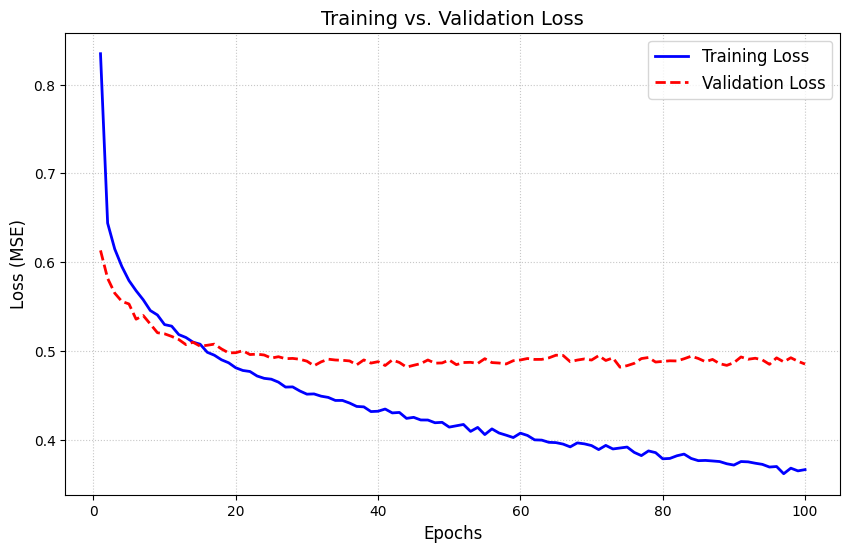

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', color='blue', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--')

plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training vs. Validation Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
#plt.ylim(0.25, 0.7) # Set y-axis limit from 0 to 2
plt.show()

In [ ]:
model_dropOut.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        # Get the raw logits from the model
        logits = model_dropOut(batch_X)

        # Get the predicted class index by finding the maximum logit
        predictions = torch.argmax(logits, dim=1)

        # batch_y is already 1D (batch_size,) from test_loader
        test_correct += (predictions == batch_y).sum().item()
        test_total += batch_y.size(0)

final_accuracy = (test_correct / test_total) * 100

print("=" * 40)
print(f"FINAL TEST ACCURACY: {final_accuracy:.2f}%")
print("=" * 40)

# Display 5 specific customer examples
print("\nSample Customer Predictions:")

# Apply softmax to get actual probabilities for display
softmax_probs = torch.softmax(logits, dim=1)

for i in range(min(5, batch_X.size(0))): # Ensure we don't go out of bounds for small batches
    # Convert back to standard numbers for printing
    predicted_class_idx = predictions[i].item()
    actual_class_idx = batch_y[i].item()

    # Get the probability for the predicted class
    prob_of_predicted_class = softmax_probs[i, predicted_class_idx].item() * 100

    # Use label_encoder to get original class names for better readability
    # label_encoder is available from previous cells
    predicted_label = label_encoder.inverse_transform([predicted_class_idx])[0]
    actual_label = label_encoder.inverse_transform([actual_class_idx])[0]

    # Format the text to make it easy to read
    print(f"Customer {i+1}: Model predicted {predicted_label} (Certainty: {prob_of_predicted_class:.1f}%) | Actual: {actual_label}")


FINAL TEST ACCURACY: 81.61%

Sample Customer Predictions:
Customer 1: Model predicted Class_4 (Certainty: 61.3%) | Actual: Class_2
Customer 2: Model predicted Class_6 (Certainty: 93.1%) | Actual: Class_6
Customer 3: Model predicted Class_6 (Certainty: 100.0%) | Actual: Class_6
Customer 4: Model predicted Class_8 (Certainty: 98.5%) | Actual: Class_8
Customer 5: Model predicted Class_8 (Certainty: 93.2%) | Actual: Class_8


In [ ]:
model_dropOut.eval()
train_correct = 0
train_total = 0

with torch.no_grad():
    for batch_X, batch_y in train_loader:
        # Get the raw logits from the model
        logits = model_dropOut(batch_X)

        # Get the predicted class index by finding the maximum logit
        predictions = torch.argmax(logits, dim=1)

        # batch_y is already 1D (batch_size,) from test_loader
        train_correct += (predictions == batch_y).sum().item()
        train_total += batch_y.size(0)

final_accuracy = (train_correct / train_total) * 100

print("=" * 40)
print(f"FINAL TEST ACCURACY: {final_accuracy:.2f}%")
print("=" * 40)

# Display 5 specific customer examples
print("\nSample Customer Predictions:")

# Apply softmax to get actual probabilities for display
softmax_probs = torch.softmax(logits, dim=1)

for i in range(min(5, batch_X.size(0))): # Ensure we don't go out of bounds for small batches
    # Convert back to standard numbers for printing
    predicted_class_idx = predictions[i].item()
    actual_class_idx = batch_y[i].item()

    # Get the probability for the predicted class
    prob_of_predicted_class = softmax_probs[i, predicted_class_idx].item() * 100

    # Use label_encoder to get original class names for better readability
    # label_encoder is available from previous cells
    predicted_label = label_encoder.inverse_transform([predicted_class_idx])[0]
    actual_label = label_encoder.inverse_transform([actual_class_idx])[0]

    # Format the text to make it easy to read
    print(f"Customer {i+1}: Model predicted {predicted_label} (Certainty: {prob_of_predicted_class:.1f}%) | Actual: {actual_label}")


FINAL TEST ACCURACY: 90.07%

Sample Customer Predictions:
Customer 1: Model predicted Class_3 (Certainty: 61.5%) | Actual: Class_2
Customer 2: Model predicted Class_2 (Certainty: 96.1%) | Actual: Class_2
Customer 3: Model predicted Class_6 (Certainty: 100.0%) | Actual: Class_6
Customer 4: Model predicted Class_9 (Certainty: 99.4%) | Actual: Class_9
Customer 5: Model predicted Class_2 (Certainty: 75.4%) | Actual: Class_2


In [ ]:
torch.save(model_dropOut.state_dict(), 'OttoNetDropout.pt')

**why don't we use drop out before activation?**

While there isn't a strict rule that forbids placing dropout before activation, the common and often recommended practice is to place dropout after the activation function. Here's why:

- **Zeroing out activations:** Dropout's primary mechanism is to randomly set a fraction of activations to zero. If you apply dropout before an activation function like ReLU, sigmoid, or tanh:

   - For ReLU, ReLU(0) is still 0, so the effect of dropout isn't completely negated for zeroed values. However, ReLU only activates positive values, so applying dropout before it means you might be zeroing out values that would have become positive.
   - For sigmoid or tanh, sigmoid(0) is 0.5 and tanh(0) is 0. If dropout sets an input to 0, the activation function would then map it to 0.5 or 0 respectively, which isn't truly 'dropping out' the neuron's contribution in the way intended (especially for sigmoid where 0 becomes 0.5).

- **Information flow:** The idea of dropout is to randomly drop out the output of a neuron, meaning the information that has already been processed by the linear transformation and the non-linearity. This forces the subsequent layers to be more robust to missing information from various neurons.

So, placing dropout after the activation function (Linear -> Activation -> Dropout) ensures that the neuron's output, after undergoing its non-linear transformation, is either passed through or completely shut off, effectively forcing the network to learn more robust features.

<br> <br>



## **Regularization**

A regularizer in machine learning is a technique used to prevent overfitting—when a model learns the training data too well (including noise) and performs poorly on new data. Regularization works by adding a penalty to the model’s loss function, discouraging overly complex models.

#### **Intuition:**

- **Without regularization:** Model may assign very large weights to fit training data perfectly.

- **With regularization:** Model is encouraged to keep weights small and simple, leading to better generalization.

<br>

#### **Common Types of Regularization:**

- **L2 Regularization (Ridge or Weight Decay):** Adds penalty proportional to squared weights.

  Formula:

  $$
  \text{Loss} = \text{OriginalLoss} + \lambda \sum w^2
  $$

  Smoothly shrinks weights (most common).

  **How to use in PyTorch:**

  ```
  import torch
  import torch.nn as nn
  import torch.optim as optim

  model = nn.Linear(10, 1)
  optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.001)
  ```
  - weight_decay = λ (regularization strength)
  - Automatically applies L2 regularization during optimization

<br>


- **L1 Regularization (Lasso):** Adds penalty proportional to absolute weights.


  Formula:

  $$
  \text{Loss} = \text{OriginalLoss} + \lambda \sum |w|
  $$

  Encourages sparsity (many weights become zero).

  **How to use in PyTorch:**

  PyTorch doesn’t include L1 directly in optimizers, so you add it manually:



  ```
  l1_lambda = 0.001
  l1_norm = sum(p.abs().sum() for name, p in model.named_parameters() if "bias" not in name)
  loss = original_loss + l1_lambda * l1_norm
  ```

`p.abs().sum()`: Calculates the L1 norm for a single parameter tensor p. A parameter tensor typically represents the weights of a specific layer in your neural network.

`.sum()` : adds up all those absolute values





## **Full Code with regularizer**

In [ ]:
model_dropOut = OttoNet_dropOut()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_dropOut.parameters(), lr=0.001, weight_decay=1e-4) # Add L2 regularization

In [ ]:
epochs = 100
train_losses, val_losses = [], []

for epoch in range(epochs):
    # --- TRAINING ---
    model_dropOut.train()
    epoch_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model_dropOut(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    # --- VALIDATION ---
    model_dropOut.eval()
    epoch_val_loss = 0
    correct_guesses = 0
    total_guesses = 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            raw_predictions = model_dropOut(batch_X)
            loss = criterion(raw_predictions, batch_y)
            epoch_val_loss += loss.item()

            # Get the predicted class index by finding the maximum logit
            predicted_classes = torch.argmax(raw_predictions, dim=1)

            # Count how many match the true labels
            correct_guesses += (predicted_classes == batch_y).sum().item()
            total_guesses += batch_y.size(0)

    val_losses.append(epoch_val_loss / len(val_loader))

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}] |Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}')



Epoch [10/100] |Train Loss: 0.5367 | Val Loss: 0.5216
Epoch [20/100] |Train Loss: 0.4878 | Val Loss: 0.5053
Epoch [30/100] |Train Loss: 0.4597 | Val Loss: 0.4882
Epoch [40/100] |Train Loss: 0.4429 | Val Loss: 0.4882
Epoch [50/100] |Train Loss: 0.4262 | Val Loss: 0.4872
Epoch [60/100] |Train Loss: 0.4207 | Val Loss: 0.4955
Epoch [70/100] |Train Loss: 0.4081 | Val Loss: 0.4922
Epoch [80/100] |Train Loss: 0.4034 | Val Loss: 0.4930
Epoch [90/100] |Train Loss: 0.3965 | Val Loss: 0.4954
Epoch [100/100] |Train Loss: 0.3922 | Val Loss: 0.5005


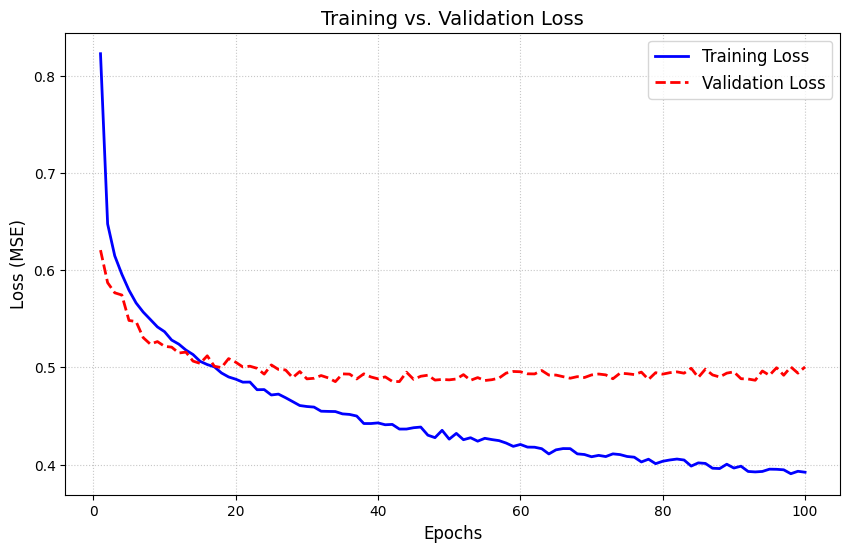

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', color='blue', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--')

plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training vs. Validation Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
#plt.ylim(0.25, 0.7) # Set y-axis limit from 0 to 2
plt.show()

In [ ]:
model_dropOut.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        # Get the raw logits from the model
        logits = model_dropOut(batch_X)

        # Get the predicted class index by finding the maximum logit
        predictions = torch.argmax(logits, dim=1)

        # batch_y is already 1D (batch_size,) from test_loader
        test_correct += (predictions == batch_y).sum().item()
        test_total += batch_y.size(0)

final_accuracy = (test_correct / test_total) * 100

print("=" * 40)
print(f"FINAL TEST ACCURACY: {final_accuracy:.2f}%")
print("=" * 40)

# Display 5 specific customer examples
print("\nSample Customer Predictions:")

# Apply softmax to get actual probabilities for display
softmax_probs = torch.softmax(logits, dim=1)

for i in range(min(5, batch_X.size(0))): # Ensure we don't go out of bounds for small batches
    # Convert back to standard numbers for printing
    predicted_class_idx = predictions[i].item()
    actual_class_idx = batch_y[i].item()

    # Get the probability for the predicted class
    prob_of_predicted_class = softmax_probs[i, predicted_class_idx].item() * 100

    # Use label_encoder to get original class names for better readability
    # label_encoder is available from previous cells
    predicted_label = label_encoder.inverse_transform([predicted_class_idx])[0]
    actual_label = label_encoder.inverse_transform([actual_class_idx])[0]

    # Format the text to make it easy to read
    print(f"Customer {i+1}: Model predicted {predicted_label} (Certainty: {prob_of_predicted_class:.1f}%) | Actual: {actual_label}")


FINAL TEST ACCURACY: 81.68%

Sample Customer Predictions:
Customer 1: Model predicted Class_4 (Certainty: 42.1%) | Actual: Class_2
Customer 2: Model predicted Class_6 (Certainty: 85.7%) | Actual: Class_6
Customer 3: Model predicted Class_6 (Certainty: 100.0%) | Actual: Class_6
Customer 4: Model predicted Class_8 (Certainty: 98.9%) | Actual: Class_8
Customer 5: Model predicted Class_8 (Certainty: 93.9%) | Actual: Class_8


In [ ]:
model_dropOut.eval()
train_correct = 0
train_total = 0

with torch.no_grad():
    for batch_X, batch_y in train_loader:
        # Get the raw logits from the model
        logits = model_dropOut(batch_X)

        # Get the predicted class index by finding the maximum logit
        predictions = torch.argmax(logits, dim=1)

        # batch_y is already 1D (batch_size,) from test_loader
        train_correct += (predictions == batch_y).sum().item()
        train_total += batch_y.size(0)

final_accuracy = (train_correct / train_total) * 100

print("=" * 40)
print(f"FINAL TEST ACCURACY: {final_accuracy:.2f}%")
print("=" * 40)

# Display 5 specific customer examples
print("\nSample Customer Predictions:")

# Apply softmax to get actual probabilities for display
softmax_probs = torch.softmax(logits, dim=1)

for i in range(min(5, batch_X.size(0))): # Ensure we don't go out of bounds for small batches
    # Convert back to standard numbers for printing
    predicted_class_idx = predictions[i].item()
    actual_class_idx = batch_y[i].item()

    # Get the probability for the predicted class
    prob_of_predicted_class = softmax_probs[i, predicted_class_idx].item() * 100

    # Use label_encoder to get original class names for better readability
    # label_encoder is available from previous cells
    predicted_label = label_encoder.inverse_transform([predicted_class_idx])[0]
    actual_label = label_encoder.inverse_transform([actual_class_idx])[0]

    # Format the text to make it easy to read
    print(f"Customer {i+1}: Model predicted {predicted_label} (Certainty: {prob_of_predicted_class:.1f}%) | Actual: {actual_label}")


FINAL TEST ACCURACY: 88.36%

Sample Customer Predictions:
Customer 1: Model predicted Class_3 (Certainty: 56.3%) | Actual: Class_2
Customer 2: Model predicted Class_8 (Certainty: 97.9%) | Actual: Class_8
Customer 3: Model predicted Class_2 (Certainty: 90.5%) | Actual: Class_2
Customer 4: Model predicted Class_6 (Certainty: 100.0%) | Actual: Class_6
Customer 5: Model predicted Class_3 (Certainty: 52.1%) | Actual: Class_2


<br><br>

## **What is Batch Normalization?**

Batch Normalization (BatchNorm) is a technique used in neural networks to stabilize and speed up training by normalizing the activations (outputs) of a layer.

During training, the distribution of activations keeps changing as weights update. This is sometimes called internal covariate shift.

BatchNorm fixes this by:

- Keeping activations centered (mean ≈ 0)
- Keeping them scaled (variance ≈ 1)

This makes learning more stable and allows higher learning rates.

#### **What it does mathematically**

For a batch of inputs $x$:

**1. Compute mean and variance:**

$$
\mu = \frac{1}{m} \sum x, \quad
\sigma^2 = \frac{1}{m} \sum (x - \mu)^2
$$

**2. Normalize:**

$$
\hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}
$$

**3. Scale and shift (learnable parameters):**

$$
y = \gamma \hat{x} + \beta
$$

- $\gamma$: scale (learned)  
- $\beta$: shift (learned)  
- $\epsilon$: small constant for numerical stability


<br>

**Subtle but important insight:**

> BatchNorm doesn’t just normalize—it changes the optimization landscape, making gradients smoother and easier to work with.


> BatchNorm is not trying to change the **range** of the activation (like tanh’s -1 to 1). It’s trying to control the **distribution** of inputs going into the activation.


Activation function like tanh, defines a fixed output range:tanh(x)∈[−1,1]

BatchNorm, controls the mean and variance of the input to tanh, not its final range

<br>

**Where to place it?** `Linear/Conv → BatchNorm → ReLU`

<br>

**Important behaviors:Training vs Inference**
- Training: uses batch statistics (mean & variance of current batch)
- Inference: uses running averages learned during training (overall mean and variance of the entire training dataset.)

> Without model.eval(), your predictions would change every run depending on batch composition.

```
model.train()  # training mode
model.eval()   # inference mode (very important!)
```

<br>

**Why it helps?**

- Faster convergence
- Allows higher learning rates
- Reduces sensitivity to initialization
- Acts as a mild regularizer (like a small amount of noise)

###  **model.train() vs model.eval()**

| Mode | What it does | Dropout behavior | BatchNorm behavior | Overall behavior |
|------|-------------|------------------|--------------------|------------------|
| `model.train()`  | Sets model to training mode | Randomly drops neurons (regularization ON) | Uses batch statistics (mean & variance of current batch) and updates running averages | Stochastic (randomness ON), learns from batch statistics |
| `model.eval()`  | Sets model to inference/testing mode | Dropout is turned OFF (no neurons dropped) | Uses running mean & variance (no updates) | Deterministic (stable outputs), uses learned statistics |

<br>

**Very important clarification:**

These modes do NOT change:

- weights
- architecture
- loss function
- optimizer

They only change **layer behavior during forward pass**.

## **Full Code with BN**

In [ ]:
class OttoNet_BN(nn.Module):
    def __init__(self, ):
        super().__init__()

        self.layer1 = nn.Linear(93, 512)
        self.bn1 = nn.BatchNorm1d(512)

        self.layer2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)

        self.layer3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)

        self.out = nn.Linear(128, 9) # 9 target classes

        self.relu = nn.ReLU()
        #self.dropout = nn.Dropout(0.5)

    def forward(self, x):
          # Layer 1
          x = self.layer1(x)
          x = self.bn1(x)
          x = self.relu(x)
          x = self.dropout(x)

          # Layer 2
          x = self.layer2(x)
          x = self.bn2(x)
          x = self.relu(x)
          x = self.dropout(x)

          # Layer 3
          x = self.layer3(x)
          x = self.bn3(x)
          x = self.relu(x)

          return self.out(x)

model_BN = OttoNet_BN()
model_BN

OttoNet_BN(
  (layer1): Linear(in_features=93, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer3): Linear(in_features=256, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (out): Linear(in_features=128, out_features=9, bias=True)
  (relu): ReLU()
)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_BN.parameters(), lr=0.001)

In [ ]:
epochs = 100
train_losses, val_losses = [], []

for epoch in range(epochs):
    # --- TRAINING ---
    model_BN.train()
    epoch_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model_BN(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    # --- VALIDATION ---
    model_BN.eval()
    epoch_val_loss = 0
    correct_guesses = 0
    total_guesses = 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            raw_predictions = model_BN(batch_X)
            loss = criterion(raw_predictions, batch_y)
            epoch_val_loss += loss.item()

            # Get the predicted class index by finding the maximum logit
            predicted_classes = torch.argmax(raw_predictions, dim=1)

            # Count how many match the true labels
            correct_guesses += (predicted_classes == batch_y).sum().item()
            total_guesses += batch_y.size(0)

    val_losses.append(epoch_val_loss / len(val_loader))

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}] |Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}')



Epoch [10/100] |Train Loss: 0.3583 | Val Loss: 0.5349
Epoch [20/100] |Train Loss: 0.2508 | Val Loss: 0.6358
Epoch [30/100] |Train Loss: 0.1857 | Val Loss: 0.7296
Epoch [40/100] |Train Loss: 0.1466 | Val Loss: 0.8333
Epoch [50/100] |Train Loss: 0.1251 | Val Loss: 0.8977
Epoch [60/100] |Train Loss: 0.1061 | Val Loss: 1.0002
Epoch [70/100] |Train Loss: 0.0903 | Val Loss: 1.0787
Epoch [80/100] |Train Loss: 0.0835 | Val Loss: 1.1389
Epoch [90/100] |Train Loss: 0.0737 | Val Loss: 1.1540
Epoch [100/100] |Train Loss: 0.0672 | Val Loss: 1.2235


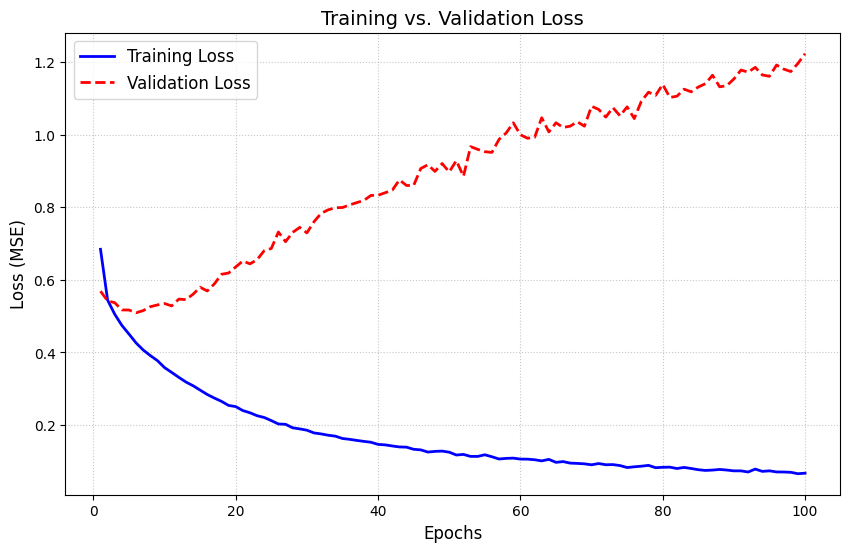

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', color='blue', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--')

plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training vs. Validation Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
#plt.ylim(0.25, 0.7) # Set y-axis limit from 0 to 2
plt.show()

In [ ]:
model_BN.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        # Get the raw logits from the model
        logits = model_BN(batch_X)

        # Get the predicted class index by finding the maximum logit
        predictions = torch.argmax(logits, dim=1)

        # batch_y is already 1D (batch_size,) from test_loader
        test_correct += (predictions == batch_y).sum().item()
        test_total += batch_y.size(0)

final_accuracy = (test_correct / test_total) * 100

print("=" * 40)
print(f"FINAL TEST ACCURACY: {final_accuracy:.2f}%")
print("=" * 40)

# Display 5 specific customer examples
print("\nSample Customer Predictions:")

# Apply softmax to get actual probabilities for display
softmax_probs = torch.softmax(logits, dim=1)

for i in range(min(5, batch_X.size(0))): # Ensure we don't go out of bounds for small batches
    # Convert back to standard numbers for printing
    predicted_class_idx = predictions[i].item()
    actual_class_idx = batch_y[i].item()

    # Get the probability for the predicted class
    prob_of_predicted_class = softmax_probs[i, predicted_class_idx].item() * 100

    # Use label_encoder to get original class names for better readability
    # label_encoder is available from previous cells
    predicted_label = label_encoder.inverse_transform([predicted_class_idx])[0]
    actual_label = label_encoder.inverse_transform([actual_class_idx])[0]

    # Format the text to make it easy to read
    print(f"Customer {i+1}: Model predicted {predicted_label} (Certainty: {prob_of_predicted_class:.1f}%) | Actual: {actual_label}")


FINAL TEST ACCURACY: 80.10%

Sample Customer Predictions:
Customer 1: Model predicted Class_2 (Certainty: 98.7%) | Actual: Class_2
Customer 2: Model predicted Class_6 (Certainty: 99.9%) | Actual: Class_6
Customer 3: Model predicted Class_6 (Certainty: 100.0%) | Actual: Class_6
Customer 4: Model predicted Class_8 (Certainty: 99.9%) | Actual: Class_8
Customer 5: Model predicted Class_8 (Certainty: 100.0%) | Actual: Class_8


In [ ]:
model_BN.eval()
train_correct = 0
train_total = 0

with torch.no_grad():
    for batch_X, batch_y in train_loader:
        # Get the raw logits from the model
        logits = model_BN(batch_X)

        # Get the predicted class index by finding the maximum logit
        predictions = torch.argmax(logits, dim=1)

        # batch_y is already 1D (batch_size,) from test_loader
        train_correct += (predictions == batch_y).sum().item()
        train_total += batch_y.size(0)

final_accuracy = (train_correct / train_total) * 100

print("=" * 40)
print(f"FINAL TEST ACCURACY: {final_accuracy:.2f}%")
print("=" * 40)

# Display 5 specific customer examples
print("\nSample Customer Predictions:")

# Apply softmax to get actual probabilities for display
softmax_probs = torch.softmax(logits, dim=1)

for i in range(min(5, batch_X.size(0))): # Ensure we don't go out of bounds for small batches
    # Convert back to standard numbers for printing
    predicted_class_idx = predictions[i].item()
    actual_class_idx = batch_y[i].item()

    # Get the probability for the predicted class
    prob_of_predicted_class = softmax_probs[i, predicted_class_idx].item() * 100

    # Use label_encoder to get original class names for better readability
    # label_encoder is available from previous cells
    predicted_label = label_encoder.inverse_transform([predicted_class_idx])[0]
    actual_label = label_encoder.inverse_transform([actual_class_idx])[0]

    # Format the text to make it easy to read
    print(f"Customer {i+1}: Model predicted {predicted_label} (Certainty: {prob_of_predicted_class:.1f}%) | Actual: {actual_label}")


FINAL TEST ACCURACY: 98.64%

Sample Customer Predictions:
Customer 1: Model predicted Class_9 (Certainty: 100.0%) | Actual: Class_9
Customer 2: Model predicted Class_4 (Certainty: 64.1%) | Actual: Class_4
Customer 3: Model predicted Class_3 (Certainty: 99.9%) | Actual: Class_3
Customer 4: Model predicted Class_4 (Certainty: 56.7%) | Actual: Class_3
Customer 5: Model predicted Class_8 (Certainty: 100.0%) | Actual: Class_8


In [ ]:
torch.save(model_BN.state_dict(), 'OttoNetBN.pt')